<a href="https://colab.research.google.com/github/aramis-lab/leaspy_tutorial/blob/main/notebooks/fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# On Colab the tutorial's own files (tutolib/, content/) are cloned from GitHub.
# DEVS: to test your OWN branch, set BRANCH below to it AND open this notebook
# from that branch (File > Open notebook > GitHub > branch dropdown). Leave
# BRANCH = "main" on the main branch. To re-pull after pushing new commits,
# delete the leaspy_tutorial folder (or factory-reset the runtime).
BRANCH = "main"
REPO = "https://github.com/aramis-lab/leaspy_tutorial"

import importlib.util, pathlib, subprocess, sys

try:  # find_spec raises (not returns None) when there is no `google` package at all
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
pip = [sys.executable, "-m", "pip", "install", "-q"]

if IN_COLAB:
    if importlib.util.find_spec("leaspy") is None:
        subprocess.run(pip + ["--no-deps",
    "leaspy @ git+https://github.com/aramis-lab/leaspy.git@v2.1.0"], check=True)
        subprocess.run(pip + ["lifelines"], check=True)   # dep Colab may lack
    if not pathlib.Path("leaspy_tutorial").exists():
        subprocess.run(["git", "clone", "-q", "--branch", BRANCH, REPO], check=True)
    ROOT = pathlib.Path("leaspy_tutorial")
else:
    # running from a clone: walk up from the notebook until we find the repo root
    ROOT = next(p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
                if (p / "tutolib").is_dir())
sys.path.insert(0, str(ROOT))

import tutolib as tp
print("tutolib", tp.__version__, "loaded from", ROOT)

tutolib 0.1.0 loaded from leaspy_tutorial


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

import leaspy
from leaspy.datasets import load_dataset
from leaspy.io.data import Data
from leaspy.models import LogisticModel
from leaspy.io.logs.visualization.plotting import Plotting

print(f"leaspy {leaspy.__version__}")



leaspy 2.1.0


# Data

Leaspy is a library for analyzing **longitudinal data**: repeated observations of the same subjects over time. To use it, your data needs to be loaded in a specific format.

Leaspy expects data as a **pandas DataFrame** with:
- a `MultiIndex` of `(ID, TIME)`, where `ID` identifies the subject and `TIME` is the age (or time) at each visit
- one column per **feature**

Additionally, for the logistic model, each feature must be:
- **increasing with disease severity** (a higher value = more progressed disease)
- **normalized between 0 and 1**

Real-world data rarely satisfies this out of the box — some scores decrease with severity, others aren't on a `[0, 1]` scale. Let's look at an example.

In [3]:
df_raw = pd.read_csv(tp.asset_path("data_raw.csv"), index_col=["ID", "TIME"])
df_raw.head()

Feature_1  Feature_2
ID       TIME                        
132-S2-0 81.661        4.0        1.0
         82.136        0.0        1.0
         82.682        4.0        1.0
         83.139        0.0        1.0
         83.691        0.0        1.0

In [4]:
# Check the range of each feature
df_raw.agg(["min", "max"])

,Feature_1,Feature_2
min,0.0,0.0
max,100.0,1.0


In [5]:
# Check whether each feature tends to increase or decrease with TIME, on average
corr = df_raw.reset_index("TIME").groupby("ID").apply(lambda x: x.corr(numeric_only=True)["TIME"]).mean().drop("TIME").rename_axis(None)
pd.DataFrame({
    "correlation": corr,
    "trend": np.where(corr > 0, "increasing", "decreasing"),
})

,correlation,trend
Feature_1,0.398877,increasing
Feature_2,-0.294871,decreasing


`Feature_1` ranges from 0 to 100 and is positively correlated with time — it just needs to be rescaled to `[0, 1]`. `Feature_2` is already in `[0, 1]`, but negatively correlated with time — it decreases with disease severity, so we'll need to invert it. Let's fix both.

In [6]:
df_clean = df_raw.copy()

### Normalize a feature

`Feature_1` ranges between 0 and 100 and is already increasing with disease severity. Rescale it to `[0, 1]` in df_clean.

In [7]:
tp.solution(1)

### Invert a decreasing feature

`Feature_2` ranges between 0 and 1 but *decreases* with disease progression. Transform it in df_clean so it increases with severity.

In [8]:
tp.solution(2)

### Keep subjects with at least 2 visits

Leaspy needs repeated observations per subject to estimate a trajectory, so we only keep subjects seen at least twice.

In [9]:
# Check for patients with only one visit
n_visits = df_clean.groupby("ID").size()
n_single_visit = (n_visits == 1).sum()
print(f"{n_single_visit} out of {n_visits.shape[0]} patients have only one visit.")

2 out of 250 patients have only one visit.


Now, keep only the subjects with **at least 2 visits**.

In [10]:
tp.solution(3)

## From here on: the Parkinson dataset

Now that you've seen how to bring raw data into the right format, we'll use a dataset that is **already preprocessed**: Leaspy's built-in synthetic Parkinson's disease dataset, with 200 subjects and three normalized clinical scores.

In [11]:
df = load_dataset("parkinson")
FEATURES = ["MDS1_total", "SCOPA_total", "MOCA_total"]
SEED = 0
df = df[FEATURES]
print(df.head())

n_subjects = df.index.get_level_values("ID").nunique()
print(f"{n_subjects} subjects in the dataset.")

avg_visits = df.groupby("ID").size().mean()
print(f"Average number of visits per subject: {avg_visits:.1f}")

                  MDS1_total  SCOPA_total  MOCA_total
ID     TIME                                          
GS-001 71.354607    0.112301     0.160001    0.275257
       71.554604    0.140880     0.135852    0.380934
       72.054604    0.225499     0.211134    0.351172
       73.054604    0.132519     0.245323    0.377842
       73.554604    0.278923     0.223102    0.292768
200 subjects in the dataset.
Average number of visits per subject: 10.0


### Train / test split

As with any predictive model, we hold out a subset of subjects as a **test set**, kept aside from model fitting. This lets us later check how well the model generalizes to subjects it hasn't seen during training.

In [12]:
# Train / test split
df_train = df.loc[:"GS-160"]
df_test = df.loc["GS-161":]
data_train = Data.from_dataframe(df_train)
data_test = Data.from_dataframe(df_test)
train_ids = df_train.index.unique("ID")
test_ids = df_test.index.unique("ID")
print(f"Train : {len(train_ids)} subjects")
print(f"Test  : {len(test_ids)} subjects")

Train : 160 subjects
Test  : 40 subjects


In [13]:
df_train.head()

MDS1_total  SCOPA_total  MOCA_total
ID     TIME                                          
GS-001 71.354607    0.112301     0.160001    0.275257
       71.554604    0.140880     0.135852    0.380934
       72.054604    0.225499     0.211134    0.351172
       73.054604    0.132519     0.245323    0.377842
       73.554604    0.278923     0.223102    0.292768

### Spaghetti plots

A good first step before fitting any model is to visualize the raw trajectories. 
Using `df_train`, plot the trajectories of each feature (one color per feature) as a function of age, with one line per subject (**spaghetti plot** of the data).

In [14]:
tp.solution(4)

# Fit

Once we have a dataset that is ready for leaspy, we have to choose which model to fit in our data.

For now the available models are:
- `LogisticModel`
- `LinearModel`
- `JointModel`
- `LogisticMultivariateMixtureModel`

For this example we will run a logistic model. Since we have three scores we will run a multivariate model wo se need to choose beforehand the number of sources.

*Reminder:* The sources represent the groups of scores that evolve in a similar way. It should be a number smaller that the total number of features.

In [ ]:
tp.runquestion(1)

In [ ]:
# Load the model
model_2_sources = LogisticModel(name="logistic", source_dimension=2)

In [17]:
# Fit the model
MODEL_2_LOGS = Path("_outputs") / "model_2_sources"

model_2_sources.fit(
    df_train, "mcmc_saem",
    seed=SEED, n_iter=1000, progress_bar=True,
    save_periodicity=50,
    path=MODEL_2_LOGS,
    overwrite_logs_folder=True,
)

/usr/local/lib/python3.12/dist-packages/leaspy/algo/settings.py:86: UserWarning: The logs path you provided (/content/_outputs/model_2_sources) does not exist. Needed paths will be created (and their parents if needed).
  self._create_root_folder(settings)


|##################################################|   1000/1000 iterations

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 33.70s


In [18]:
# Save the model
model_2_sources.save(MODEL_2_LOGS / "model_parameters.json")

## Convergence assessment

The model is estimated via an MCMC-SAEM. It is an iterative algorithm that lies in a stochastic approximation. Before interpreting the results of our fit we should check if the model has converged. In simple words we should see if the final estimations are stable and if the chains had explored adequately the parameter space.

During the fit, the value of every estimated parameter is recorded each `save_periodicity` iterations into a `.csv` file under `_outputs/model_2_sources/parameter_convergence/`. Those files are what we plot below.

Read the traces from left to right: early on they drift as the algorithm searches, then they should settle into a flat band that only jitters. The dashed line marks the end of the **burn-in** phase, after which leaspy starts averaging, so it is the flatness *to the right of it* that tells you the fit has converged.

In [19]:
PARAMS = ["tau_mean", "tau_std", "xi_std", "noise_std", "g", "v0"]

def plot_convergence(folder, params=PARAMS, features=FEATURES, burn_in=None):
    """Plot one MCMC trace per parameter, straight from the CSVs leaspy saved.
    """
    fig, axes = plt.subplots(3, 2, figsize=(11, 9))
    for ax, name in zip(axes.flat, params):
        trace = pd.read_csv(Path(folder) / f"{name}.csv", index_col=0, header=None)
        if trace.shape[1] == len(features):
            trace.columns = features  # one curve per score, so label them
        trace.plot(ax=ax, lw=1, legend=False)
        end_of_burn_in = burn_in if burn_in is not None else 0.9 * trace.index.max()
        ax.axvline(end_of_burn_in, ls="--", c="0.5")  # end of burn-in
        ax.set_title(name)
        ax.set_xlabel("")

    handles = [plt.Line2D([], [], color=f"C{i}") for i in range(len(features))]
    fig.legend(handles, features, loc="upper center", ncol=len(features), frameon=False)
    fig.supxlabel("iteration")
    fig.tight_layout(rect=(0, 0, 1, 0.96))  # leave a strip at the top for the legend

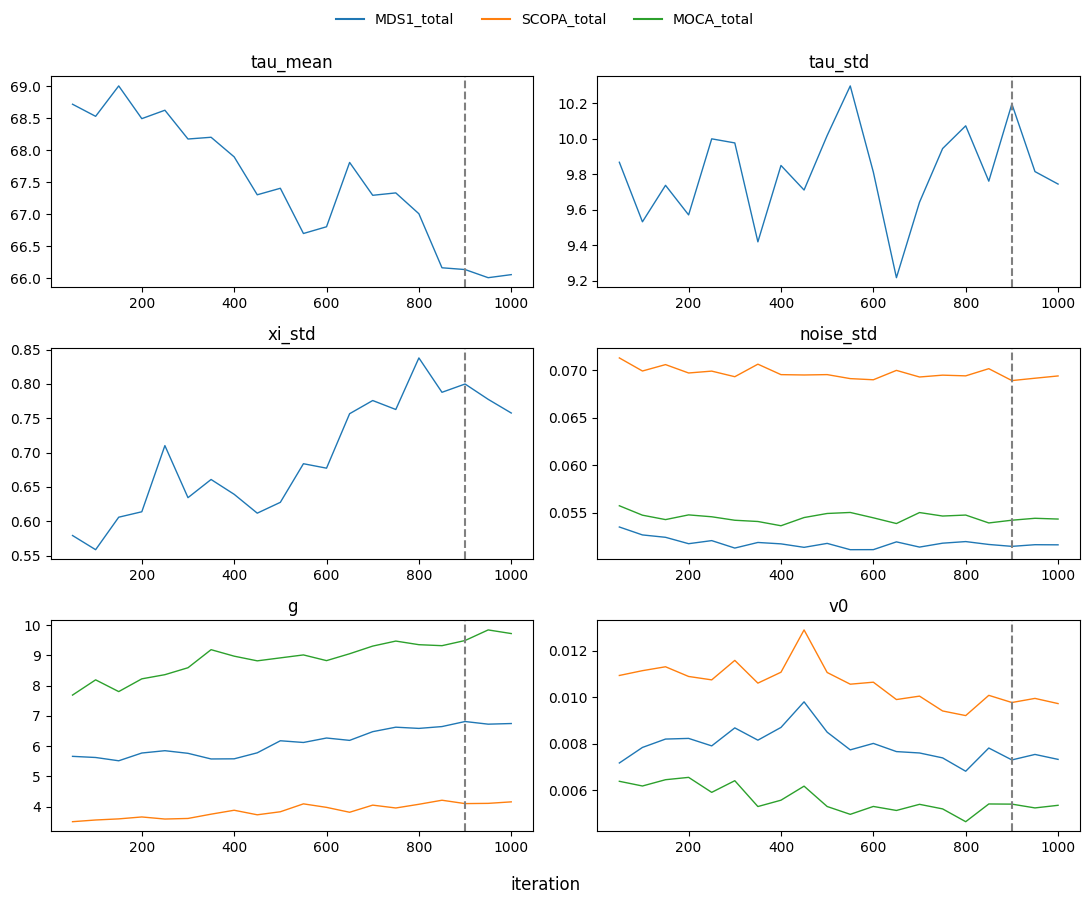

In [20]:
# Your own fit wrote one CSV per parameter into MODEL_2_LOGS/parameter_convergence/.
plot_convergence(MODEL_2_LOGS / "parameter_convergence")
plt.show()

### Question

Take a look at the convergence plots above before answering.

In [21]:
tp.runquestion(2)

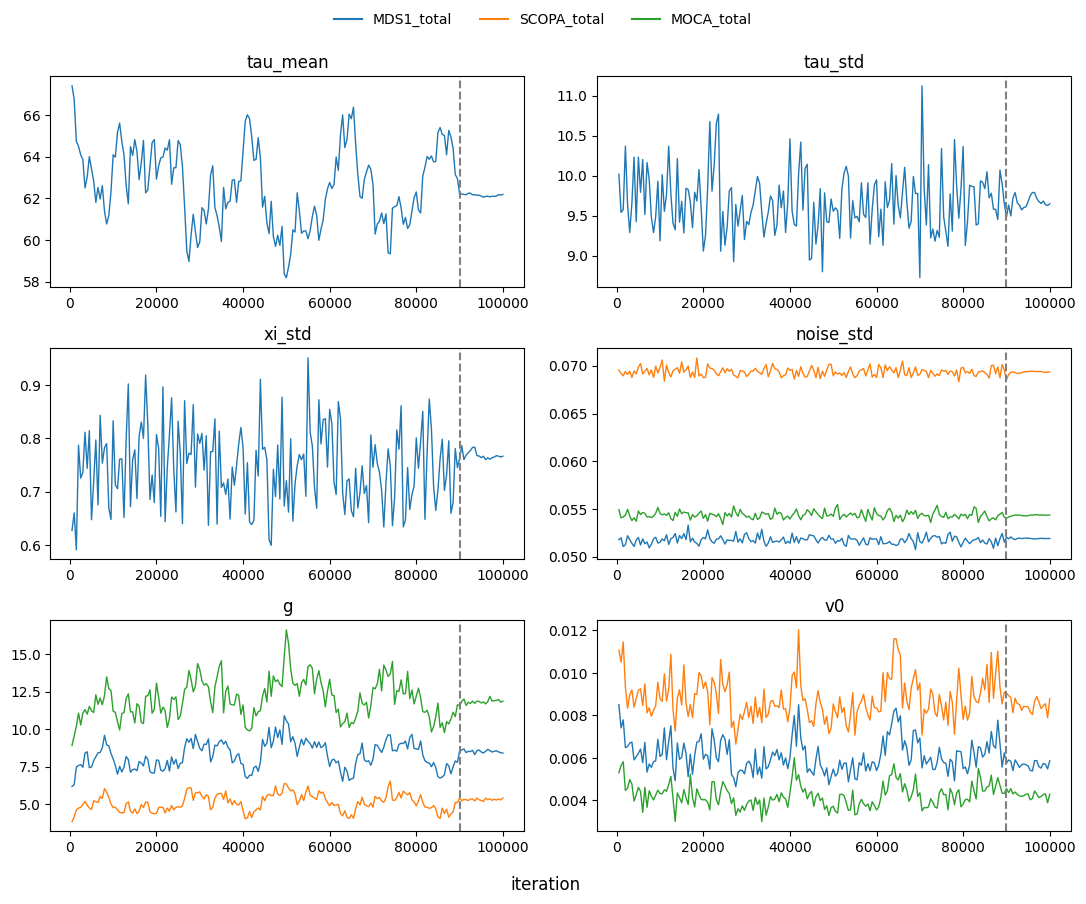

In [22]:
# The canonical 100 000-iteration run shipped with the tutorial
RUN = ROOT / "content" / "reference_run"

plot_convergence(RUN / "parameter_convergence")
plt.show()

**Note:** as shown above, 1000 iterations are not enough for the model to fully converge, so the parameters you just fitted are not the ones you would report in a real analysis.

Rather than draw conclusions from an under-converged fit, we ship the **converged** model: the result of that same 100 000-iteration run, saved to a JSON file. Loading it is instant, so from here on we can look at trustworthy parameters and trajectories without anyone waiting 11 minutes.

In [23]:
# Restoring a saved fit is a one-liner: same class, same API as the model you fitted above
model_100k = LogisticModel.load(str(RUN / "parkinson_fit_V21.json"))

print(type(model_100k).__name__, model_100k.features, f"source_dimension={model_100k.source_dimension}")
# on a loaded model these two are plain dicts, so they are read with [] not a dot
print(f"trained for {model_100k.training_info['n_iter']} iterations "
      f"on {model_100k.dataset_info['n_subjects']} subjects")

LogisticModel ['MDS1_total', 'SCOPA_total', 'MOCA_total'] source_dimension=2
trained for 100000 iterations on 160 subjects


## Model summary

Now that we have a model with a satisfactory convergence, we can look at its fit output via the integrated `summary()` function. Everything from here on reports `model_100k`, the converged fit -- not the 1000-iteration one you trained above.

In [24]:
model_100k.summary()

                                 Model Summary                                  
Model Name: logistic
Model Type: LogisticModel
Features (3): MDS1_total, SCOPA_total, MOCA_total
Sources (2): Source 0 (s0), Source 1 (s1)
Observation Models: gaussian-diagonal
Neg. Log-Likelihood: -5592.5337
Parameters: 19
BIC: -13517.14
AIC: -13575.57

Training Metadata
--------------------------------------------------------------------------------
Algorithm: mcmc_saem
Seed: 0
Iterations: 100000

Data Context
--------------------------------------------------------------------------------
Subjects: 160
Visits: 1590
Total Observations: 4770
Leaspy Version: 2.1.0

Population Parameters
--------------------------------------------------------------------------------
  betas_mean:
                          s0        s1
            b0        0.0511    0.0038
            b1       -0.0232    0.0402
                    MDS1_to.  SCOPA_t.  MOCA_to.
  log_g_mean          2.1357    1.6673    2.4747
               

We can show specific elements such as the metrics:

In [25]:
summary = model_100k.summary()
print(f"BIC: {float(summary.bic)}")
print(f"AIC: {float(summary.aic)}")

BIC: -13517.142010010557
AIC: -13575.5703125


Or a specific set of parameters

In [26]:
model_100k.summary().parameters['Individual Parameters']

{'tau_mean': tensor([62.1939]),
 'tau_std': tensor([9.6497]),
 'xi_std': tensor([0.7668])}

## Plotting

We can plot the population trajectories of the converged model with leaspy's internal plotting tool.

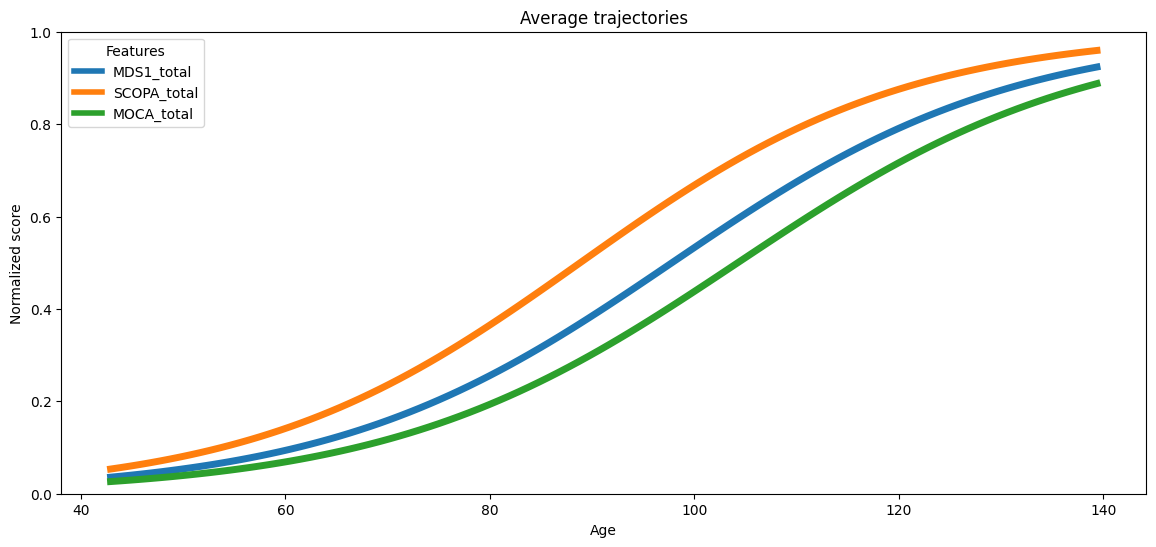

In [27]:
ax = Plotting(model_100k).average_trajectory(
    alpha=1, figsize=(14, 6), n_std_left=2, n_std_right=8
)
plt.show()

In [28]:
tp.show_asset("sigmoid_interactive.html")

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Model Comparison

The exercises below use `model_2_sources`, the 1,000-iteration fit, together with other deliberately short fits.

AIC and BIC should be compared on the same observations only after every candidate model has converged. Because the 1,000-iteration fits in this section are intentionally under-converged, the exercise demonstrates the comparison API but its ranking should not be used for scientific model selection. A real comparison would fit every candidate until its traces stabilize, preferably across multiple seeds.

### Task 1: Vary the number of sources

Can you load and fit a logistic model with one source and compare it with the previous model?

model_1_source = ...

In [29]:
# If you need help, run this cell to get the code
# Click `Show Solution` to see the answer
tp.solution(5)

In [30]:
# Now compare the two models with their BIC / AIC
tp.solution(6)

In [31]:
tp.runquestion(3)

### Task 2: Vary the noise model

The default choice is to fit a `gaussian-diagonal` noise, which means that we fit a noise with a separate standard deviation per score


In [32]:
model_2_sources.observation_model_names

['gaussian-diagonal']

Another option is to fit a `gaussian-scalar` noise, which means fitting one global standard deviation for the noise shared between all the scores.

We just have to add the argument `obs_models='gaussian-scalar'` when we load our model.

In [33]:
tp.runquestion(4)

In [34]:
# Fit a 1-source model with a scalar noise
tp.solution(7)

Let's fit also a model with 2 sources and a scalar noise and compare the four models all together.

In [35]:
# Fit a 2-source model with a scalar noise
tp.solution(8)

In [36]:
# Compare the four models with their BIC / AIC
tp.solution(9)

# Personalization and prediction

## Personalize on the train set

Fitting the model gives us **population-level** parameters — the average trajectory. But each patient deviates from this average: some start progressing earlier or later, some progress faster or slower. The `personalize` function estimates the **individual parameters** for each subject, conditional on the population parameters estimated during fit — namely, the time-shift $\tau_i$, the log-acceleration $\xi_i$, and the sources $s_i$, which together fully characterize a subject's individual trajectory.

From now on, we use the model fitted with 100 000 iterations (rather than the 1000-iteration model used earlier for the comparisons), since we now care about the quality of individual trajectories rather than just running fast comparisons.

Here we use `scipy_minimize`, a deterministic optimization method. Bayesian alternatives based on MCMC sampling are also available.

In [37]:
ip_train = model_100k.personalize(data_train, "scipy_minimize", seed=SEED, progress_bar=True)

|#####################################################|   159/160 subjects

Personalize with `AlgorithmName.PERSONALIZE_SCIPY_MINIMIZE` took: 1m 41.63s


This gives us, for each subject, their individual parameters. For instance, for patient `GS-001`:

In [38]:
print(ip_train["GS-001"])

{'sources': [-1.4965848922729492, 0.8067296147346497], 'tau': [68.58268737792969], 'xi': [1.4487327337265015]}


In the model summary of model_100k, we have seen that `tau_mean = 62.19` (the population's average disease onset age). Here, patient `GS-001` has `tau = 68.58` and a **log-acceleration factor** `xi = 1.45`.

In [39]:
tp.runquestion(5)

In [40]:
tp.runquestion(6)

We can verify this visually by plotting GS-001's individual trajectory alongside the population average.

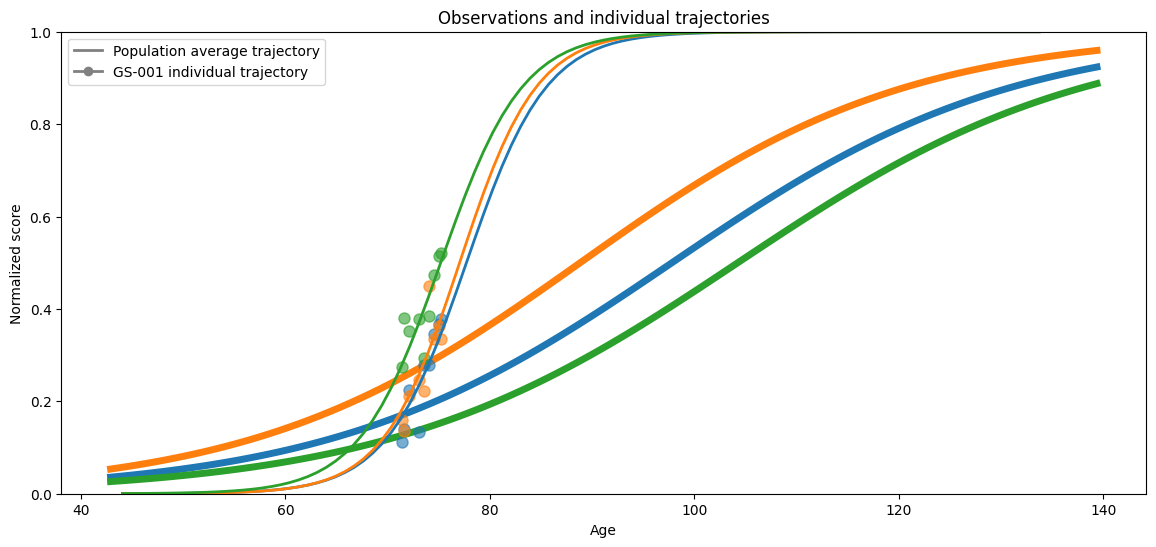

In [41]:
fig, ax = plt.subplots(figsize=(14, 6))
ax = Plotting(model_100k).average_trajectory(alpha=1, n_std_left=2, n_std_right=8, ax=ax)
ax = Plotting(model_100k).patient_trajectories(
    data_train, ip_train,
    patients_idx=["GS-001"],
    alpha=1, linestyle="-", linewidth=2, markersize=8, obs_alpha=0.6,
    figsize=(13, 5), factor_past=7, factor_future=15, ax=ax
)
ax.plot([], [], color="gray", linewidth=2, label="Population average trajectory")
ax.plot([], [], color="gray", linewidth=2, linestyle="-", marker="o", label="GS-001 individual trajectory")
ax.legend()
plt.show()

As expected, GS-001 indeed starts deteriorating later than the average patient, but progresses faster once the disease sets in.

### Reparametrized time

Each patient has their own pace: a personal onset age (`tau_i`) and a personal acceleretation factor (`xi_i`). **Reparametrized time** removes this individual variability, projecting every patient's trajectory onto the same underlying timeline.

Once reparametrized, patient trajectories should align closely with the population average trajectory. Let's check this by comparing the spaghetti plot in reparametrized time to the one in raw time (age) from earlier.

/tmp/ipykernel_1068/3753510165.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


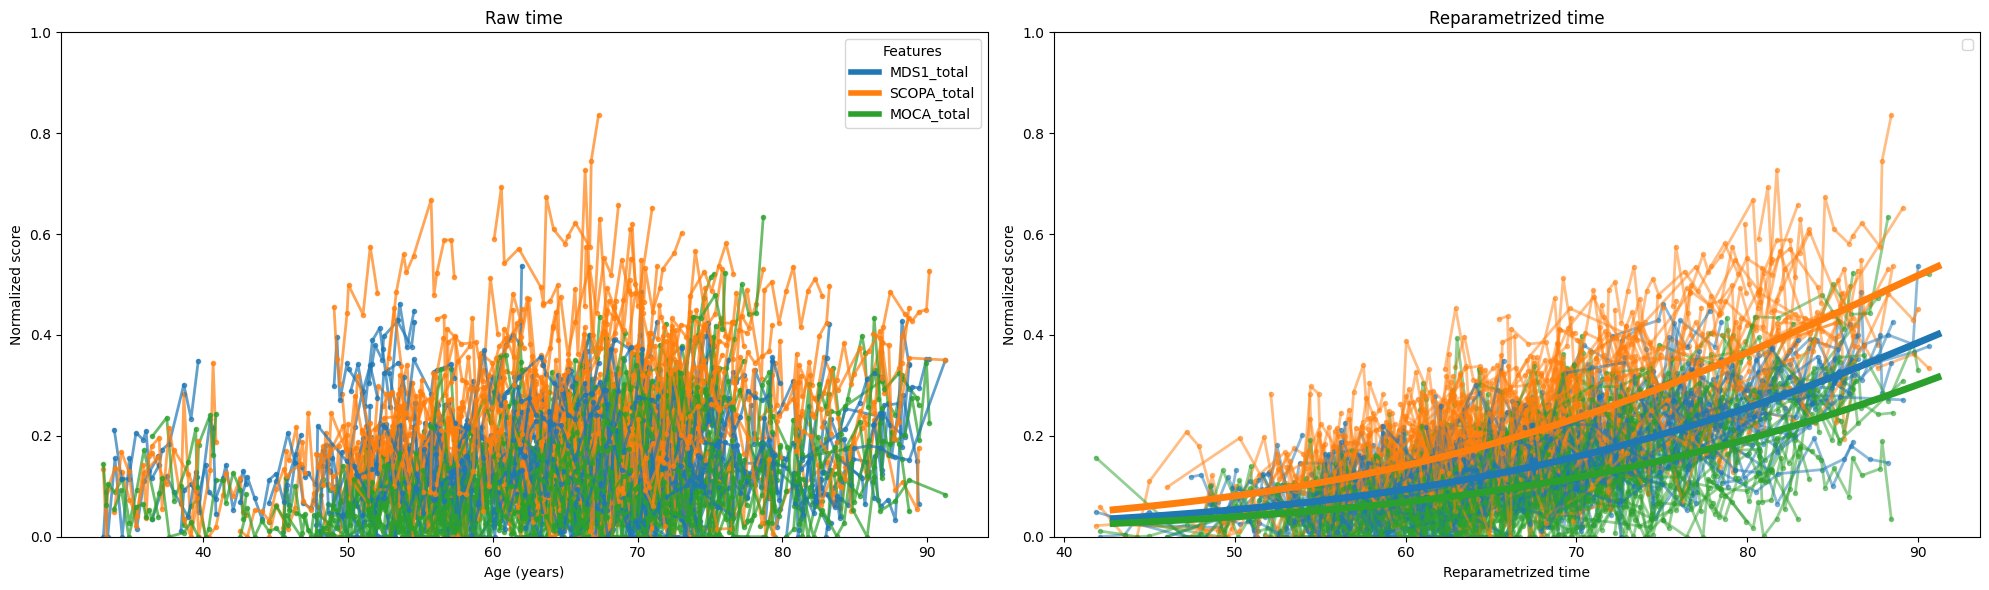

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Raw time
ax = axes[0]
ax = Plotting(model_100k).patient_observations(
    data_train, alpha=0.7, ax=ax
)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Normalized score")
ax.set_title("Raw time")

# Reparametrized time
ax = axes[1]
ax = Plotting(model_100k).patient_observations_reparametrized(
    data_train, ip_train, alpha=0.5, linestyle="-", ax=ax
)
ax = Plotting(model_100k).average_trajectory(
    alpha=1, n_std_left=2, n_std_right=3, ax=ax
)
ax.set_xlabel("Reparametrized time")
ax.set_ylabel("Normalized score")
ax.set_title("Reparametrized time")
ax.legend()

plt.tight_layout()
plt.show()

The contrast is clear: in raw age, patient trajectories are spread out and hard to compare. In reparametrized time, they collapse around the population average trajectory.

## Predictions on the test set

Now that we understand how the `personalize` function access **individual parameters** for each subject, we can see how we can use these parameters to predict the progression of patients.

To do this, we use the test set, which contains patients not seen during model fitting. For each patient, we remove their last visit from the data used for personalization. Leaspy then estimates the patient's individual parameters using only their previous visits. These parameters are subsequently used to predict the feature values at the withheld final visit.

In [43]:
tp.runquestion(7)

In [44]:
# Load the data
df_test_partial = df_test.groupby("ID").apply(lambda x: x.iloc[:-1]).droplevel(0) # create the partial test set (without last visit)
data_test_partial = Data.from_dataframe(df_test_partial)

df_test_last = df_test.groupby("ID").tail(1) # create the test set with only the last visit (for evaluation metrics)

In [45]:
# Compute the individual parameters for the test set without last visit with the 100k-iteration model
# Call the object "ip_test"
tp.solution(10)

NameError: name 'ip_test' is not defined

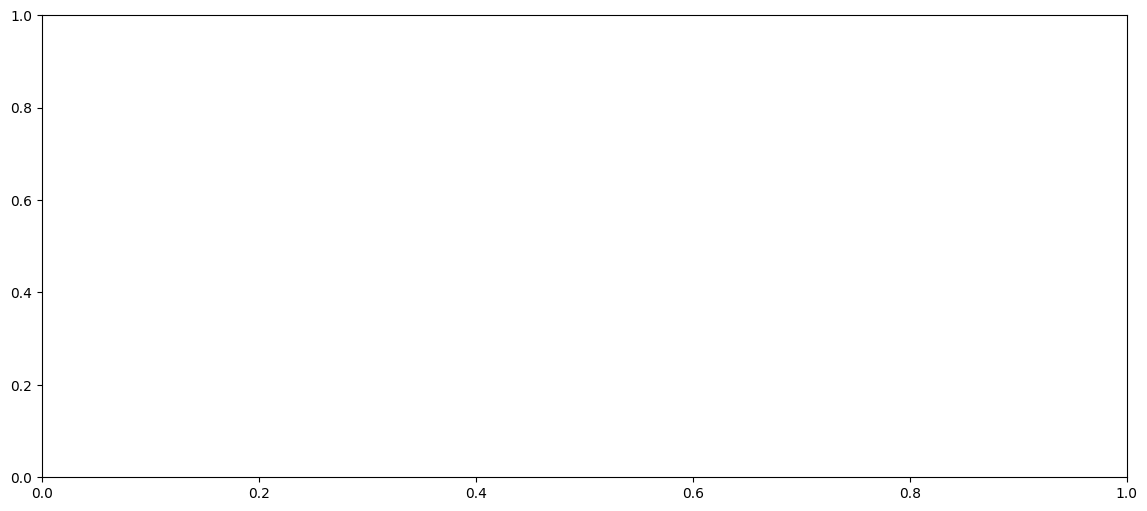

In [46]:
# Plot individual trajectory for GS-184, with last observation marked
fig, ax = plt.subplots(figsize=(14, 6))
ax = Plotting(model_100k).patient_trajectories(
    data_test_partial, ip_test,
    patients_idx=["GS-184"],
    alpha=1, linestyle="-", linewidth=2, markersize=8, obs_alpha=0.6,
    figsize=(13, 5), factor_past=2, factor_future=4, ax=ax
)
for feature in ["MDS1_total", "SCOPA_total", "MOCA_total"]:
    ax.scatter(
        df_test_last.loc["GS-184"].index.get_level_values("TIME")[0],
        df_test_last.loc["GS-184"][feature].values[0],
        marker="^",  
        zorder=10,
        s = 120,
        linewidth=0.7,
        label=f"{feature} (true last observation)",
    )

ax.plot([], [], color="gray", linewidth=2, linestyle="-", marker="o", label="GS-184 individual trajectory")
ax.legend()
plt.show()

In the plot above, each feature trajectory is generated from the individual parameters `ip_test` estimated for patient GS-184. The triangle represents the true value at the final visit, which was intentionally removed before personalization.

Predicting this held-out value consists of evaluating the patient's estimated trajectory at the corresponding visit time $t$. This can be done using Leaspy's `estimate` function, which returns the predicted value of each feature along the trajectory.

In [ ]:
# Compute predictions at last visit time using estimate function
predicted_last = model_100k.estimate(df_test_last.index, ip_test)
for feature in FEATURES:
    mae = mean_absolute_error(df_test_last[feature], predicted_last[feature])
    r2  = r2_score(df_test_last[feature], predicted_last[feature])
    print(f"{feature}: MAE={mae:.3f}, R²={r2:.3f}")

MDS1_total: MAE=0.047, R²=0.762
SCOPA_total: MAE=0.060, R²=0.740
MOCA_total: MAE=0.047, R²=0.533


It is also possible to predict more than a single time point. Once the individual parameters have been estimated, the model can reconstruct the patient’s trajectory at any set of time points, including future visits.

In [ ]:
# Compute predictions at other timepoints for GS-184
observations = df.loc["GS-184"]
print(f"Observed ages: {observations.index.values.round(1)}")

timepoints = np.linspace(81.5, 90, 10)
predicted = model_100k.estimate({"GS-184": timepoints}, ip_test)
print("reconstruction :", predicted)

Observed ages: [74.8 75.3 76.3 76.8 77.3 77.8 78.3 79.3 79.8 80.3 80.8 81.  81.5]
reconstruction : {'GS-184': array([[0.17808923, 0.29948393, 0.31108302],
       [0.19414492, 0.32320735, 0.33381265],
       [0.21127598, 0.34787682, 0.3573417 ],
       [0.22948836, 0.37339053, 0.38157946],
       [0.24877538, 0.3996286 , 0.40642133],
       [0.2691171 , 0.4264556 , 0.43175137],
       [0.29047906, 0.45372248, 0.45744345],
       [0.3128111 , 0.4812701 , 0.48336416],
       [0.3360466 , 0.5089318 , 0.5093744 ],
       [0.36010373, 0.53653884, 0.5353341 ]], dtype=float32)}


# Simulation

In this section, we will use a fitted Leaspy model to generate and inspect a **new synthetic longitudinal cohort**.

## Data and fitted model

We keep the same three Parkinson's disease scores as in the fit practical and reuse `model_100k`, the converged model loaded earlier. This lets us spend our time on simulation rather than fitting again.

In [ ]:
print(f"Cohort on which the model was fit: {df_train.index.unique('ID').size} subjects")
print(f"Converged model: {model_100k.dimension} scores, {model_100k.source_dimension} sources")

Training cohort: 160 subjects
Converged model: 3 scores, 2 sources


## The Simulate algorithm

Leaspy generates a cohort in three steps:

1. sample each new subject's individual parameters ($\tau$, $\xi$ and sources) from the distribution learned during the fitting process;
2. generate that subject's visit times from a user-specified visit design;
3. evaluate the model at those times and add observation noise.

The result therefore resembles the fitted population, but it contains entirely new subjects.

In [ ]:
tp.runquestion(8)

## Choose the visit design

With `visit_type="random"`, visit times are controlled by the dictionary below. Times are in years.

| Parameter | Meaning |
| --- | --- |
| `patient_number` | Number of subjects to simulate. |
| `visit_type` | Method used to generate visits; `"random"` samples new schedules. |
| `first_visit_mean` | Mean first-visit offset from each subject's $\tau$. |
| `first_visit_std` | Standard deviation of the first-visit offset. |
| `time_follow_up_mean` | Mean follow-up duration. |
| `time_follow_up_std` | Standard deviation of the follow-up duration. |
| `distance_visit_mean` | Mean time between consecutive visits. |
| `distance_visit_std` | Standard deviation of the time between visits. |
| `min_spacing_between_visits` | Minimum allowed spacing; closer visits are removed. |

Here we request 150 subjects, a mean follow-up of 11 years, and visits every 0.3 years on average (about every 3.6 months). These are deliberately convenient tutorial parameters rather than an attempt to reproduce the constraints of a real cohort. One advantage of simulation is precisely this control over the study design: we can choose the cohort size, follow-up, and visit frequency needed for an experiment.

Random schedules are optional. To use a pre-made set of visit dates, set `visit_type="dataframe"` and provide `df_visits`, a dataframe containing `ID` and `TIME` columns.

In [ ]:
visit_parameters = {
    "patient_number": 150,
    "visit_type": "random",
    "first_visit_mean": 0.0,
    "first_visit_std": 0.4,
    "time_follow_up_mean": 11.0,
    "time_follow_up_std": 0.5,
    "distance_visit_mean": 0.3,
    "distance_visit_std": 0.1,
    "min_spacing_between_visits": 1 / 365,
}

visit_parameters

{'patient_number': 150,
 'visit_type': 'random',
 'first_visit_mean': 0.0,
 'first_visit_std': 0.4,
 'time_follow_up_mean': 11.0,
 'time_follow_up_std': 0.5,
 'distance_visit_mean': 0.3,
 'distance_visit_std': 0.1,
 'min_spacing_between_visits': 0.0027397260273972603}

In [ ]:
tp.runquestion(9)

### Task: generate the cohort

Call `model_100k.simulate` with the `"simulate"` algorithm, `FEATURES`, `visit_parameters`, and `SEED`. You can take inspiration from the `fit` code above. 

In [ ]:
# Complete the task in this cell or reveal and run the solution.
# simulated = ...
tp.solution(11)

In [ ]:
df_sim = simulated.data.to_dataframe().set_index(["ID", "TIME"])

## Inspect the result

The result contains both the noisy longitudinal observations and the known individual parameters that generated them. Looking at both makes the differences between simulated subjects easy to interpret.

In [ ]:
n_subjects = df_sim.index.unique("ID").size
visits_per_subject = df_sim.groupby(level="ID").size()

print(f"{n_subjects} simulated subjects")
print(f"{len(df_sim)} visits in total")
print(
    f"Visits per subject: median {visits_per_subject.median():.0f} "
    f"(range {visits_per_subject.min()}–{visits_per_subject.max()})"
)
display(df_sim.head())
display(simulated.individual_parameters.head())

150 simulated subjects
5722 visits in total
Visits per subject: median 38 (range 32–45)


MDS1_total  SCOPA_total  MOCA_total
ID TIME                                       
0  60.915    0.092882     0.139483    0.159205
   61.069    0.108419     0.010489    0.074530
   61.301    0.132105     0.146851    0.068910
   61.637    0.227803     0.116858    0.037656
   61.956    0.194354     0.104875    0.104404

,xi,tau,sources_0,sources_1,w_0,w_1,w_2
0,"tensor(1.3526, dtype=torch.float64)","tensor(61.5353, dtype=torch.float64)",-1.248050,-0.862736,0.031678,-0.058731,0.009028
1,"tensor(0.3068, dtype=torch.float64)","tensor(78.7272, dtype=torch.float64)",1.927211,0.893489,-0.035514,0.092562,-0.025358
2,"tensor(0.7504, dtype=torch.float64)","tensor(55.0072, dtype=torch.float64)",0.024732,0.558972,-0.017181,-0.001147,0.013922
3,"tensor(1.7182, dtype=torch.float64)","tensor(54.2189, dtype=torch.float64)",-0.577207,0.386584,-0.009348,-0.030512,0.024618
4,"tensor(1.4320, dtype=torch.float64)","tensor(61.2438, dtype=torch.float64)",0.865012,0.442607,-0.017210,0.041369,-0.010300


### Compare real and simulated trajectories

The first row shows real subjects and the second row shows simulated subjects. In both cohorts, subjects differ in disease timing, progression speed and spatial shift, while observation noise adds visit-to-visit variability.

In [ ]:
real_sample_ids = df.index.unique("ID")[:6]
simulated_sample_ids = df_sim.index.unique("ID")[:6]
fig, axes = plt.subplots(
    2, len(FEATURES), figsize=(14, 7), sharex=True, sharey=True
)

for feature, ax in zip(FEATURES, axes[0]):
    for subject_id in real_sample_ids:
        subject = df.loc[subject_id]
        ax.plot(subject.index, subject[feature], marker="o", ms=3, alpha=0.7)
    ax.set_title(feature)
    ax.set_ylim(0, 1)

for feature, ax in zip(FEATURES, axes[1]):
    for subject_id in simulated_sample_ids:
        subject = df_sim.loc[subject_id]
        ax.plot(subject.index, subject[feature], marker="o", ms=3, alpha=0.7)
    ax.set_xlabel("Age")
    ax.set_ylim(0, 1)

axes[0, 0].set_ylabel("Real data\nNormalized score")
axes[1, 0].set_ylabel("Simulated data\nNormalized score")
plt.tight_layout()
plt.show()

# Extension: Joint model

In this extension, we will fit a model that combines **longitudinal trajectories** with a **time-to-event outcome**. We will inspect the same calibration outputs as in the logistic fit practical, while highlighting exactly what the joint model adds.

## Joint longitudinal and survival data

We use the synthetic ALS joint dataset shipped with this workshop. It contains four normalized longitudinal outcomes and one event endpoint.

In addition to `ID`, `TIME`, and the longitudinal features, a joint dataframe needs:

| Column | Meaning |
| --- | --- |
| `EVENT_TIME` | Observed event time, or censoring time if the event was not observed. |
| `EVENT_BOOL` | `1` for an observed event and `0` for right censoring. |

Right censoring does **not** mean that the subject never experiences the event; it means that the event status is unknown after `EVENT_TIME`.

In [ ]:
from leaspy.models import JointModel

In [ ]:
DATA = ROOT / "content" / "data"

FEATURES = [
    "ALSFRS_R_BULBAR",
    "ALSFRS_R_FINE_MOTOR",
    "ALSFRS_R_GROSS_MOTOR",
    "ALSFRS_R_TOTAL",
]
SEED = 0

# Load the workshop data from the tutorial repository.
df_joint = (
    pd.read_csv(
        DATA / "simulated_data_for_joint_model.csv",
        dtype={"ID": str},
    )
    .set_index(["ID", "TIME"])
    .sort_index()
)

print(f"{df_joint.index.unique('ID').size} subjects, {len(df_joint)} visits")
display(df_joint.head())

150 subjects, 1022 visits


EVENT_TIME  EVENT_BOOL  ALSFRS_R_BULBAR  ALSFRS_R_FINE_MOTOR  \
ID  TIME                                                                   
000 33.233   40.645361           1     7.520784e-14             0.000000   
    34.276   40.645361           1     1.560653e-01             0.025897   
    35.406   40.645361           1     1.077552e-01             0.183508   
    36.551   40.645361           1     6.151454e-01             0.799267   
    37.610   40.645361           1     8.053792e-01             1.000000   

            ALSFRS_R_GROSS_MOTOR  ALSFRS_R_TOTAL  
ID  TIME                                          
000 33.233         7.714040e-122        0.000143  
    34.276          2.865906e-05        0.107026  
    35.406          2.292672e-01        0.225380  
    36.551          7.012614e-01        0.574041  
    37.610          9.482336e-01        0.792261

In [ ]:
tp.runquestion(10)

### One event record per subject

The dataframe remains visit-level, so the subject-level `EVENT_TIME` and `EVENT_BOOL` values are repeated on every visit row. For each subject, both columns must be constant.

In [ ]:
event_table = df_joint.groupby(level="ID")[["EVENT_TIME", "EVENT_BOOL"]].first()
event_counts = event_table["EVENT_BOOL"].value_counts().sort_index()

print(f"Observed events: {event_counts.get(1, 0)}")
print(f"Right-censored subjects: {event_counts.get(0, 0)}")
display(event_table.head())

Observed events: 103
Right-censored subjects: 47


,EVENT_TIME,EVENT_BOOL
ID,,
000,40.645361,1
001,63.944898,0
002,49.224329,1
003,56.175099,0
004,46.270729,1


In [ ]:
tp.runquestion(11)

### Task: create joint Leaspy data

Convert `df_joint` with `Data.from_dataframe`. Unlike an ordinary longitudinal dataset, the `data_type` must explicitly be `"joint"` so Leaspy separates the repeated measurements from the event outcome. Take a look at how we did it in the code above and fill in the missing pieces.

In [ ]:
# Complete the task in this cell or reveal and run the solution.
# data_joint = ...
tp.solution(12)

## Fit the joint model

Leaspy's joint model couples:

1. the same logistic longitudinal submodel used in the fit practical;
2. a Weibull survival submodel for the event.

Both processes share each subject's latent disease age through $\tau_i$ and $\xi_i$. With multiple longitudinal outcomes, the sources also affect event risk through coefficients $\zeta$.

Here `nb_events=1` because `EVENT_BOOL` contains only 0 and 1, and we use two sources as in the multivariate logistic example.

In [ ]:
JOINT_MODEL_PATH = RUN / "als_joint_model.json"

if JOINT_MODEL_PATH.exists():
    model = JointModel.load(str(JOINT_MODEL_PATH))
    print("Cached joint model loaded.")
else:
    model = JointModel(
        name="joint",
        nb_events=1,
        source_dimension=2,
    )
    model.fit(
        data_joint,
        "mcmc_saem",
        seed=SEED,
        n_iter=100000,
        progress_bar=True,
    )
    model.save(str(JOINT_MODEL_PATH))
    print("Joint model fitted and saved.")

Cached joint model loaded.


## What changes compared with a logistic fit?

The joint model retains every longitudinal component of the logistic model and adds an event likelihood.

| Fit output | Logistic model | Joint model |
| --- | --- | --- |
| Longitudinal observation model | Gaussian | Same Gaussian model |
| Event observation model | None | Right-censored Weibull |
| Longitudinal population parameters | $g$, $v_0$, betas, noise | Same parameters |
| Individual-parameter distributions | $\tau$, $\xi$, sources | Same shared parameters |
| Survival-specific parameters | None | $\nu$, $\rho$, and $\zeta$ |
| Likelihood and information criteria | Longitudinal observations only | Longitudinal **and** event observations |

Because the likelihoods do not contain the same outcomes, the joint model's BIC/AIC should not be directly ranked against those from the longitudinal-only fit.

### Survival-specific population parameters

The joint model adds:

- $\nu$: Weibull scale, setting the characteristic time to the event;
- $\rho$: Weibull shape, controlling whether the hazard decreases ($\rho < 1$), stays constant ($\rho = 1$), or increases ($\rho > 1$) over time;
- $\zeta$: effect of each source on the event hazard.

Leaspy stores $-\log(\nu)$ and $\log(\rho)$ internally, so we retrieve them through `summary()` and transform them back to their interpretable scales below. These survival-specific parameters have no equivalent in a logistic-only fit.

In [ ]:
summary = model.summary()
nu = np.exp(-summary.get_param("n_log_nu_mean").detach().cpu().numpy())
rho = np.exp(summary.get_param("log_rho_mean").detach().cpu().numpy())
zeta = summary.get_param("zeta_mean").detach().cpu().numpy().ravel()

survival_summary = pd.DataFrame({
    "Parameter": ["nu (scale)", "rho (shape)"]
    + [f"zeta, source {i}" for i in range(len(zeta))],
    "Estimate": np.concatenate([nu, rho, zeta]),
})
display(survival_summary.round(3))

In [ ]:
tp.runquestion(12)

## Simulation with the Joint model

`simulate` is not yet available for the joint model, but it will arrive very soon with **Leaspy v2.2**.